<a href="https://colab.research.google.com/github/tarynglover/tarynglover_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_TarynGlover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [58]:
#using colab and was getting deprecation warnings, using this to hide them
import warnings
warnings.filterwarnings("ignore")

!pip install mlxtend networkx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Load dataset
df = pd.read_csv("bread_basket.csv")

df.head()

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [59]:
df.dtypes

,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [60]:
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

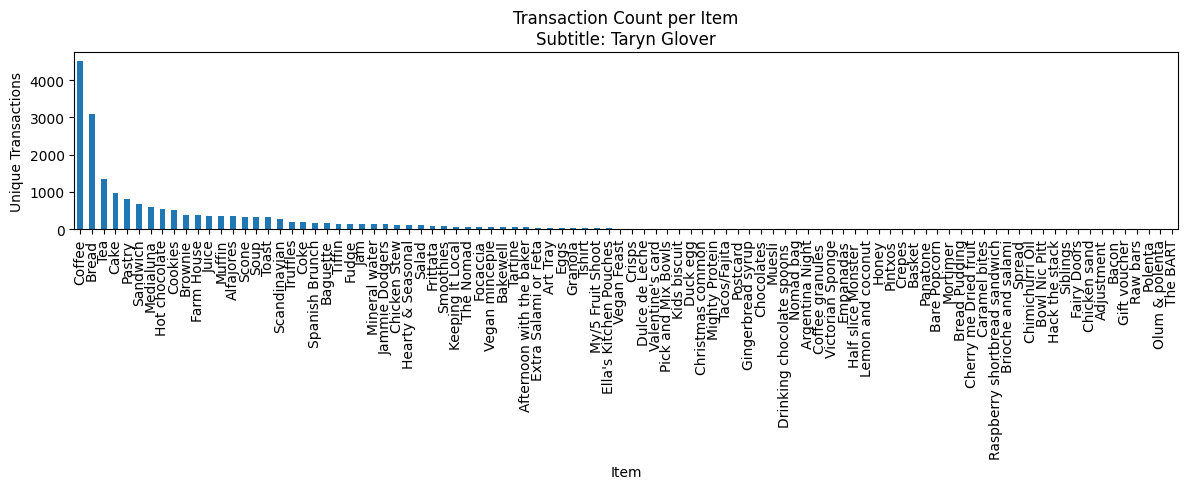

In [61]:
# bar plot
subtitle = "Taryn Glover"
item_counts =  (
    df.groupby("item")["transaction"] #grouping items
      .nunique()                      #counting unique instances
      .sort_values(ascending=False)   #sorting items
)
ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [62]:
#checking only these items
item_check = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

#counting unique transactions
count = (
    df[df["item"].isin(item_check)]
    .groupby("item")["transaction"]
    .nunique()
)

count

,transaction
item,
Alfajores,344
Chicken Stew,123
Coffee,4528
Juice,365
Tea,1350


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [63]:
#convert to list
transactions = df.groupby("transaction")["item"].apply(list).tolist()

#converting to one hot encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
oht = pd.DataFrame(te_ary, columns=te.columns_).astype(bool)

oht.head()

#running FP-growth
freq_fp = fpgrowth(oht, min_support=0.02, use_colnames=True)

freq_fp.sort_values("support", ascending=False)

,support,itemsets
5,0.478394,(Coffee)
0,0.327205,(Bread)
8,0.142631,(Tea)
12,0.103856,(Cake)
19,0.090016,"(Bread, Coffee)"
6,0.086107,(Pastry)
13,0.071844,(Sandwich)
7,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
28,0.054728,"(Coffee, Cake)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [64]:
#generating association rules
#using 25% confidence to filter out weak associations and keep meaningful ones
rules_fp = association_rules(freq_fp, metric="confidence", min_threshold=0.25)

rules_fp[['antecedents','consequents','support','confidence','lift']] \
    .sort_values('confidence', ascending=False)

,antecedents,consequents,support,confidence,lift
10,(Toast),(Coffee),0.023666,0.704403,1.472431
5,(Medialuna),(Coffee),0.035182,0.569231,1.189878
3,(Pastry),(Coffee),0.047544,0.552147,1.154168
7,(Juice),(Coffee),0.020602,0.534247,1.116750
9,(Sandwich),(Coffee),0.038246,0.532353,1.112792
8,(Cake),(Coffee),0.054728,0.526958,1.101515
2,(Cookies),(Coffee),0.028209,0.518447,1.083723
1,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311
6,(Tea),(Coffee),0.049868,0.349630,0.730840
4,(Pastry),(Bread),0.029160,0.338650,1.034977


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

Either the minimum support or the confidence level filtered out the rule {Coffee, Cake} ⇒ {Bread}, so I will look at those measures independently using dataframe filtering


In [65]:
#calculate support

#total transactions
total_tx = df["transaction"].nunique()

#fiter coffee, cake, bread
count_items = df[df["item"].isin(["Coffee", "Cake", "Bread"])]

#filter transactions for transactions that contain all 3 items
ccb_tx = (
    count_items
        .groupby("transaction")["item"]
        .nunique()
        .eq(3)
        .sum()
)

#calculate support: fraction of total that contain coffee, cake, bread
support_ccb = ccb_tx / total_tx

round(support_ccb,4)

np.float64(0.01)

In [66]:
#calculate confidence

#support of coffee, cake from FP-growth table
cc_support = 0.054728

# Confidence
confidence_ccb = support_ccb / cc_support

round(confidence_ccb,6)

np.float64(0.183397)

In [67]:
#calculate lift

support_bread =  	0.327205 #from fp-growth table

lift_value = confidence_ccb / support_bread

round(lift_value,6)

np.float64(0.560497)

The rule {Coffee, Cake} ⇒ {Bread} means that customers that purchase coffee and cake are likely to also purchase bread in the same transaction.

The support I calculated indicates that about 1% of all transactions contain coffee, cake, and bread together. (probably why it was filtered out)

The confidence I calculated was about 18%,  meaning about 18% of customers who buy coffee and cake will also purchase bread. This measure is somewhat reliable, but not the strongest.

The lift was less than one (.56 < 1), which is a negative association, and leads me to conclude that customers that purchase both coffee and cake are less likely than average to also buy bread.


>